# Whole analysis for TES till date. 

- Take data and plot parameters for number of transitions and transition time (use 1000 iterations data)
- Time spent in sync state using SEM
- Nodes which have high median time spent and high degree
- Finding connector hubs
- Finding betweenness centrality
- Finding control nodes
- All the regions get synchronised
- Time of entry in main cluster
- Finding node propagation pathway


In [66]:

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils

### Creating object


In [67]:
analyse =AnalysisFunc()
reader = DataRead()
utils=DataUtils()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


## Plot of number of transitions and transition times


In [3]:
# load data 
data_folder = Path("../../data/results/processed/")
files=glob.glob(str(data_folder / "itr*.bz2"))

# Initialize a dictionary to store parameter lists
tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states

for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")

    # Compute parameters
    params = analyse.compute_param(df_d, 0.05)

    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params["trans"]
    sync_params[f"{name_suffix}"] = params["sync"]




Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 359]
Number of transition [6, 7, 12, 22, 23, 26, 27, 29, 30, 35, 37, 43, 44, 47, 48, 54, 57, 59, 62, 63, 64, 66, 67, 69, 73, 78, 79, 85, 92, 93, 98, 104, 106, 109, 110, 112, 115, 117, 121, 125, 130, 134, 135, 141, 142, 145, 148, 149, 151, 156, 158, 159, 162, 166, 168, 172, 173, 177, 180, 181, 182, 184, 187, 191, 192, 193, 197, 198, 210, 211, 214, 218, 223, 224, 226, 227, 228, 229, 232, 237, 239, 245, 246, 247, 250, 258, 262, 264, 274, 281, 283, 295, 296, 297, 298, 303, 305, 314, 320, 322, 326, 328, 329, 333, 334, 336, 342, 343, 345, 347, 348, 350, 351, 356, 359, 360, 365, 368, 370, 371, 375, 378, 382, 384, 385, 392, 395, 396, 397, 399, 402, 410, 412, 414, 416, 424, 425, 426, 430, 431, 439, 443, 451, 454, 455, 456, 460, 465, 470, 474, 476, 482, 484, 492, 498, 501, 502, 504, 505, 506, 508, 509, 511, 512, 514, 520, 531, 533, 536, 563, 566, 568, 574, 576, 582, 587, 588, 589, 593, 595, 597, 599, 601, 602, 6

In [4]:
node_order=np.array(["fn", "bla", "enti", "orbi", "peri", "pir", "re"])

non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]

non




array([4, 1, 2, 5, 3, 6, 0])

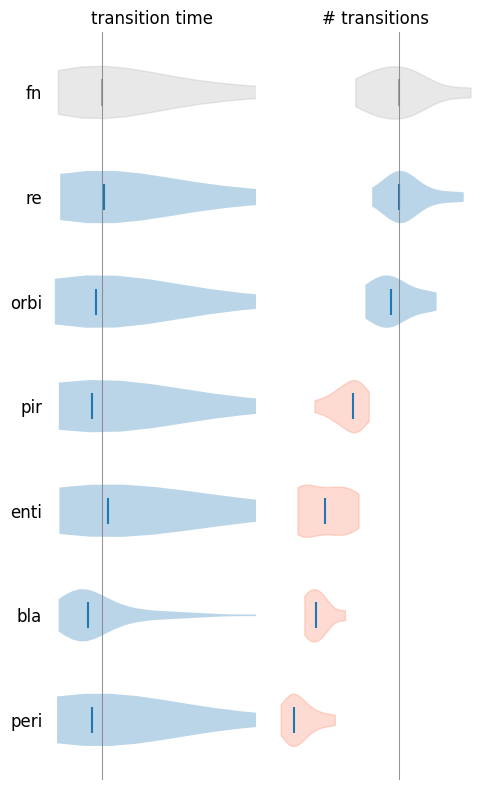

In [5]:
f,(ax1,ax2)= plt.subplots(1,2, figsize=(5,8), sharey=True)

_artists = ax1.violinplot(
    [trans_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


_artists = ax2.violinplot(
    [np.diff(np.array(tranPer_params[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()



## Time spent in sync state
 To check

In [ ]:
df=reader.data_read_bz2('results/processed/itr_peri.bz2')
plot_data=analyse.compute_time_spent(df,2000)



In [7]:
plot_data.keys()

dict_keys(['counts', 'time', 'time_spent'])

In [ ]:
data_folder = Path(f'../../data/results/processed')
print(data_folder)
# Use glob to match files with a pattern
#f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_*.bz2"))
print(files)

fig,ax = plt.subplots()

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]
    
    df_itr = pd.read_pickle(f,compression='bz2')
    df=df_itr


    bs_values = [] # list to store values
    for i in range(0,500):
        df_rand=df.sample(n=200,axis='columns') 
        df_rand.columns=list(range(0,200))
        plot_data=analyse.compute_time_spent(df_rand,2000)
        time_arr=np.array(plot_data['time'])
        count_arr = np.array(plot_data['counts'])
        y=count_arr/count_arr[0]
        bs_values.append(y)

        # coverting bs_values to df

        bs_val_df=pd.DataFrame(bs_values).T

        mean = bs_val_df.mean(axis=1)
        sem = bs_val_df.sem(axis=1)

        l=analyse.compute_time_spent(df,2000)
        t=l['time']
        # fig,ax = plt.subplots()
    ax.plot(t,mean)
    ax.errorbar(t,mean,yerr=sem,fmt='none',ecolor='k',capsize=3)
    
plt.title('Considering time spent in sync state')
plt.xlabel('Time')
plt.ylabel('Number of Iterations')
plt.legend()

../../data/results/processed
['../../data/results/processed/itr_bla.bz2', '../../data/results/processed/itr_enti.bz2', '../../data/results/processed/itr_fn.bz2', '../../data/results/processed/itr_orbi.bz2', '../../data/results/processed/itr_peri.bz2', '../../data/results/processed/itr_pir.bz2', '../../data/results/processed/itr_re.bz2']
Number of transitions / 100 iteration [1, 44, 86]
Number of transition [0, 3, 4, 7, 13, 18, 19, 21, 22, 24, 26, 28, 31, 32, 41, 51, 52, 53, 54, 59, 60, 62, 64, 65, 68, 70, 71, 73, 75, 79, 80, 82, 85, 87, 89, 95, 98, 100, 102, 106, 110, 111, 118, 122, 125, 128, 129, 133, 136, 138, 139, 143, 147, 148, 153, 155, 156, 161, 164, 165, 166, 168, 170, 176, 177, 180, 182, 188, 189, 194, 197]
Number of transition with more than one transition or a fall back [18, 19, 24, 28, 32, 51, 53, 54, 68, 71, 73, 75, 79, 82, 110, 111, 128, 129, 136, 138, 139, 143, 155, 165, 166, 170, 194]
Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 35

## Nodes which have high median time spent and high degree

In [6]:
df_nc=reader.data_read_bz2('raw/FN/nc_200.bz2')
df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')
# here G is the undirected graph
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
df_r=df_nc.reset_index(drop=True)

In [7]:
i=0
f=5000
time_list=[]
node_list=[]
while f < df_r.shape[0]:
    l=analyse.compute_time_spent_mc(df_r.iloc[i:f,:])
    node_list.append(l)
    i=f
    f+=5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape

(127, 426)

In [8]:
# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys=list(range(0,426))
mts_dict=dict(zip(keys,med_time_spent))
mts_sorted =dict(sorted(mts_dict.items(), key=lambda item: item[1]))

In [9]:
degree = nx.degree_centrality(G)
degree_val =list(degree.values())

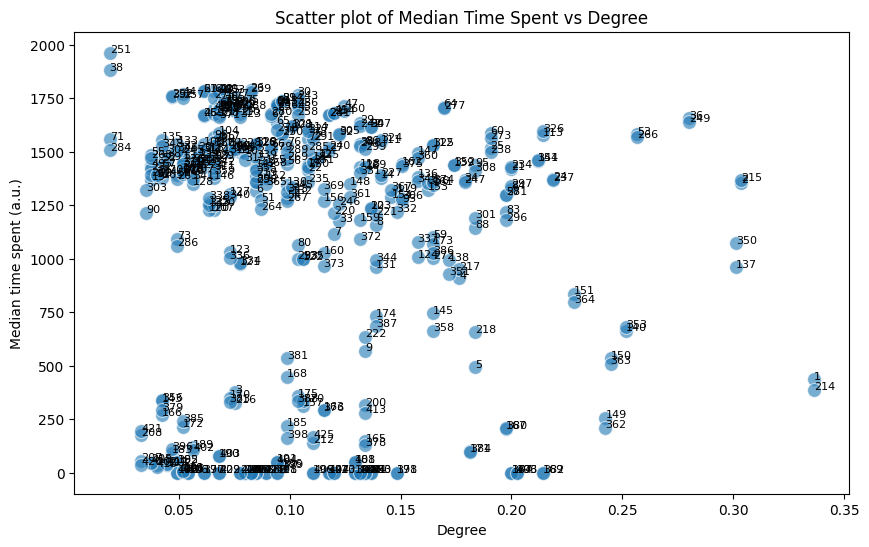

In [10]:
plt.figure(figsize=(10, 6))
ax=sns.scatterplot(x=degree_val, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')

for i, txt in enumerate(keys):
    ax.annotate(txt, (degree_val[i], med_time_spent[i]), fontsize=8)


# defining function to plot nodes wrt their color

def node_color(color_nodes,color,degree,time_spent):
    plt.figure(figsize=(10, 6))
    ax=sns.scatterplot(x=degree_val, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')
    
    for i, txt in enumerate(keys):
        ax.annotate(txt, (degree_val[i], med_time_spent[i]), fontsize=8)
    tdeg=[]
    tmts=[]
    for i in color_nodes:
        tdeg.append(degree_val[i])
        tmts.append(med_time_spent[i])
    
    ax=sns.scatterplot(x=tdeg,y=tmts,s=100,alpha=0.6,color='green')

    # Adjust the range as needed
    # plt.xlim(0, 0.15)  
    # plt.ylim(1200,1800)  
    
plt.xlabel('Degree')
plt.ylabel('Median time spent (a.u.)')
plt.title('Scatter plot of Median Time Spent vs Degree')
plt.savefig('../../data/results/mts_deg.png')

#### To color the interesting nodes, call node_color function

## Finding connector hubs 

- Nodes with high betweenness centrality, degree and nodal efficiency out of top 20 nodes
- Nodes with high betweenness centrality, high degree and high eigen vector centrality are known to be influential nodes 

In [11]:
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)

bet_cent = nx.betweenness_centrality(G)
top_betweenness_centrality= dict(sorted(bet_cent.items(), key=lambda x: x[1], reverse=True))


degree_centrality = nx.degree_centrality(G)
top_degree_centrality = dict(sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True))

deg_cent_sorted =list(top_degree_centrality.keys())[0:20]
print(f'Top degree centrality nodes:{deg_cent_sorted}')

bet_cent_sorted = list(top_betweenness_centrality.keys())[0:20]
print(f'Top betweenness centrality nodes:{bet_cent_sorted}')


eigen_centrality = nx.eigenvector_centrality(G)

top_ev_centrality = dict(sorted(eigen_centrality.items(), key=lambda x: x[1], reverse=True))

deg_ev_sorted =list(top_ev_centrality.keys())[0:20]
print(f'Top eigenvector centrality nodes:{deg_ev_sorted}')


efficiency = {}
for node in G.nodes:
    # Calculate the sum of reciprocal of shortest path lengths from the node to all other nodes
    sp_lengths = nx.shortest_path_length(G, source=node)
    sum_reciprocal_sp = sum(1 / length for length in sp_lengths.values() if length > 0)
    
    # Calculate efficiency: E(v) = (1 / (N-1)) * sum(1 / d(v, u))
    # where N is the number of nodes and d(v, u) is the shortest path length between v and u
    efficiency[node] = sum_reciprocal_sp / (len(G.nodes) - 1)
    
efficiency_sorted = dict(sorted(efficiency.items(), key=lambda item: item[1],reverse=True))

top_nodal_efficiency = list(efficiency_sorted.keys())[0:20]
print(f'Top nodal efficiency nodes:{top_nodal_efficiency}')

common_node = list(set(deg_cent_sorted) & set(bet_cent_sorted) & set(top_nodal_efficiency))
#common_node = list(set(deg_cent_sorted) & set(bet_cent_sorted) & set(top_nodal_efficiency) & set(deg_ev_sorted))
common_node

Top degree centrality nodes:[1, 214, 2, 215, 137, 350, 36, 249, 53, 266, 140, 353, 150, 363, 149, 362, 151, 364, 24, 237]
Top betweenness centrality nodes:[214, 1, 137, 350, 2, 215, 36, 249, 266, 53, 95, 308, 171, 384, 164, 377, 167, 380, 326, 113]
Top eigenvector centrality nodes:[1, 214, 215, 2, 137, 350, 364, 151, 140, 353, 150, 363, 149, 362, 36, 249, 167, 380, 24, 237]
Top nodal efficiency nodes:[1, 214, 137, 350, 2, 215, 36, 249, 140, 353, 150, 363, 149, 362, 151, 364, 53, 266, 141, 354]


[1, 2, 36, 137, 266, 53, 214, 215, 249, 350]

### Plot of nodes according to their centrality

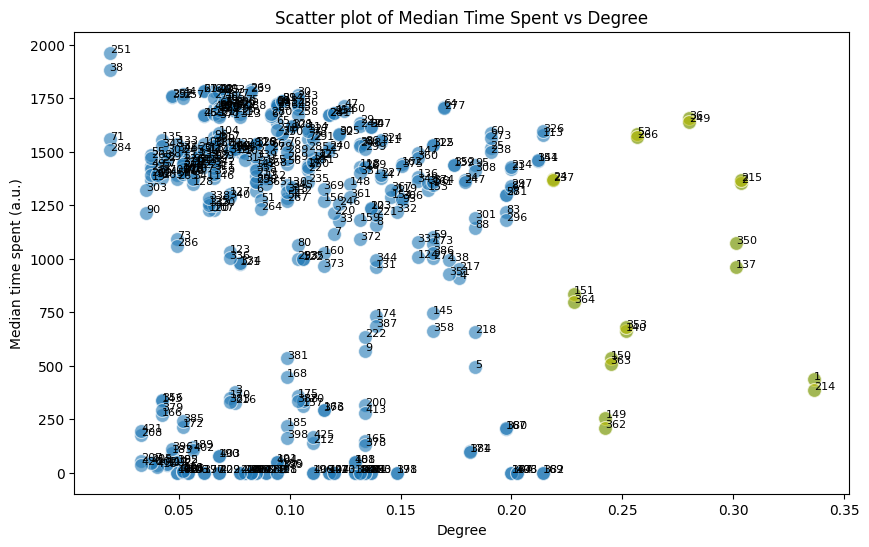

In [18]:
#fig,ax = plt.subplots(3,1,sharey=True,sharex=True)
analyse.node_color(deg_cent_sorted,'y',G,df_nc)

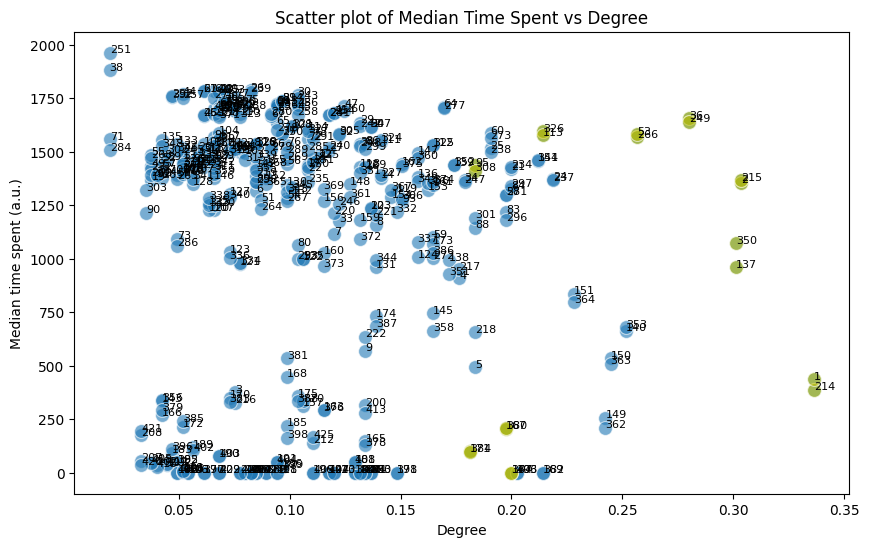

In [49]:
analyse.node_color(bet_cent_sorted,'y',G,df_nc)

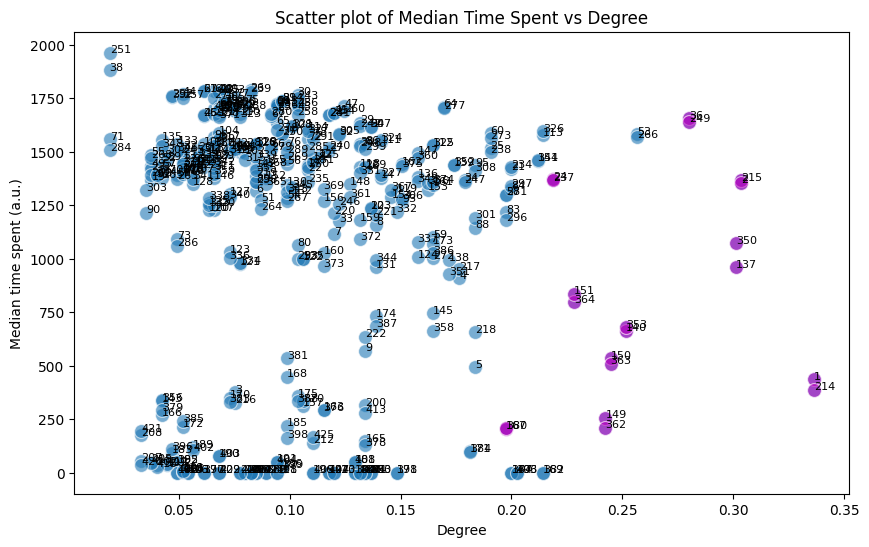

In [48]:
analyse.node_color(deg_ev_sorted,'m',G,df_nc)

### Plot parameters for connector hubs to compare 

214,1  
215,2  
249,36  
137,350  
53,266  


In [59]:
data_folder = Path('../../data/raw/check_connector/')
files=glob.glob(str(data_folder / "itr_200*.bz2"))

print(files)
x=[]
itr_count=[]

# Initialize a dictionary to store parameter lists
transition_count = {}  # to store number of transitions
transition_time = {}  # to store transition times

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    #x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    # compute parameters
    params=analyse.compute_param(df_d,0.05)

    # store lists in dictionary
    transition_count[f"{name_suffix}"] = params["tran_per"]
    transition_time[f"{name_suffix}"] = params["trans"]
    # num=l['tran_per'][-1]
    # itr_count.append(num)

['../../data/raw/check_connector/itr_200_1.bz2', '../../data/raw/check_connector/itr_200_2.bz2', '../../data/raw/check_connector/itr_200_3.bz2', '../../data/raw/check_connector/itr_200_4.bz2', '../../data/raw/check_connector/itr_200_5.bz2', '../../data/raw/check_connector/itr_200_fn.bz2']
Number of transitions / 100 iteration [1, 46, 91]
Number of transition [0, 1, 2, 3, 4, 8, 13, 14, 16, 19, 21, 25, 28, 30, 35, 39, 40, 41, 42, 45, 50, 51, 53, 55, 56, 58, 59, 62, 63, 68, 69, 70, 73, 74, 75, 78, 82, 89, 92, 97, 98, 103, 105, 107, 108, 111, 117, 120, 121, 122, 129, 132, 134, 135, 136, 137, 138, 142, 144, 148, 150, 152, 156, 158, 162, 165, 166, 167, 168, 170, 171, 173, 174, 176, 179, 180, 183, 186, 187, 188, 190, 191, 198, 199]
Number of transition with more than one transition or a fall back [14, 16, 19, 28, 42, 63, 75, 92, 98, 107, 120, 122, 144, 156, 179, 187, 190, 199]
Number of transitions / 100 iteration [0, 38, 78]
Number of transition [1, 5, 6, 10, 13, 15, 20, 25, 27, 30, 31, 34, 

In [60]:
transition_count.keys()


dict_keys(['1', '2', '3', '4', '5', 'fn'])

In [61]:
node_order = np.array(['fn','1', '2', '3', '4', '5'])
non=np.r_[np.argsort([transition_count[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]
non

array([3, 5, 4, 2, 1, 0])

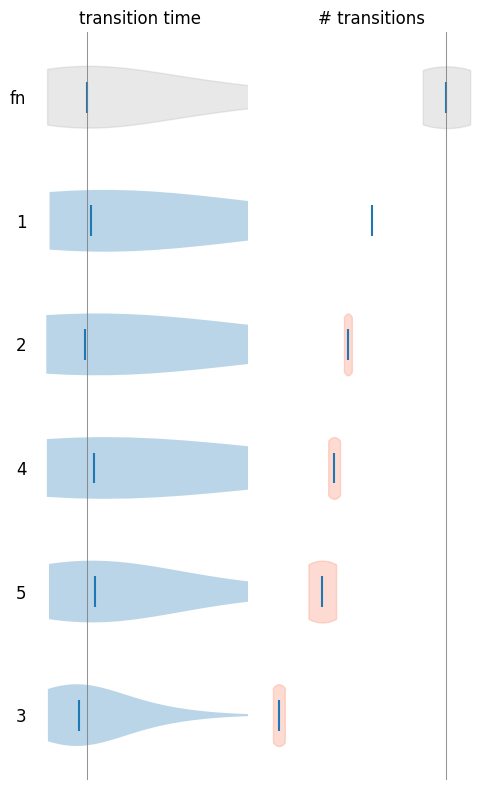

In [63]:
f,(ax1, ax2) = plt.subplots(1,2, figsize=(5,8),sharey = True)

_artists = ax1.violinplot(
    [transition_time[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(transition_time["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax2.violinplot(
    [np.diff(np.array(transition_count[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(transition_count["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()

1. 214,1
2. 215,2
3. 249,36
4. 137,350
5. 53,266

### Plotting connector nodes on time spent vs degree plot

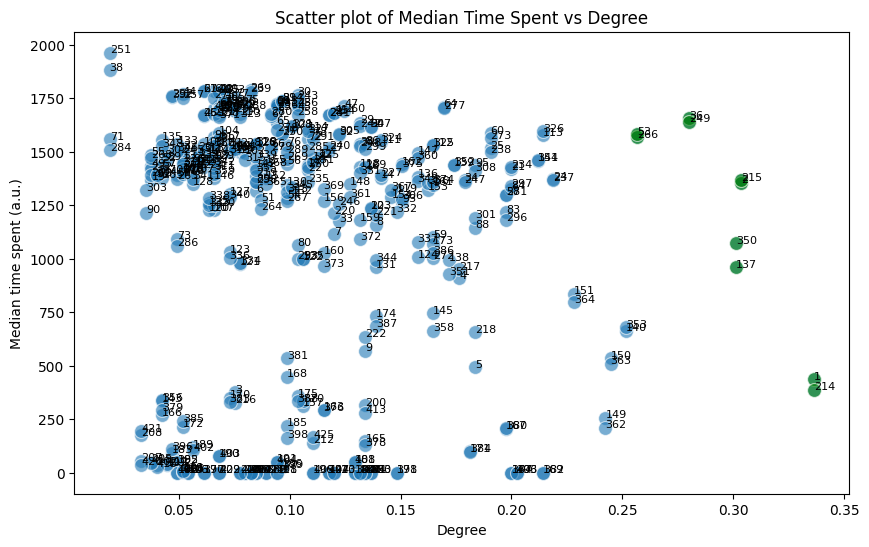

In [41]:
analyse.node_color(common_node,'g',G,df_nc)

## Nodes in order of their betwenness centrality

In [19]:
# loading nodes in descending order of their betweenness centrality
b=reader.data_read_pkl('raw/betw.pkl')

# Getting node pairs after every 20th gap

nodes=list(b.keys())
betw_nodes=[nodes[0],nodes[1]]
plot_nodes =[]
i=1
while i < 426:
    if i%20==0:
        betw_nodes.append(nodes[i-2])
        betw_nodes.append(nodes[i-1])
    i+=1
print(betw_nodes)
print(len(betw_nodes))
betw_nodes
j=0
while j < len(betw_nodes):
    plot_nodes.append(betw_nodes[j])
    
    j+=2

print(plot_nodes)
    
print(len(plot_nodes))

#storing betweenness centrality values
val=[]
for i in plot_nodes:
    val.append(b[i])

[214, 1, 326, 113, 271, 58, 301, 88, 366, 153, 242, 29, 160, 373, 33, 246, 369, 156, 122, 335, 51, 264, 114, 327, 132, 345, 213, 0, 309, 96, 334, 121, 283, 70, 50, 263, 158, 371, 32, 245, 73, 286, 303, 90]
44
[214, 326, 271, 301, 366, 242, 160, 33, 369, 122, 51, 114, 132, 213, 309, 334, 283, 50, 158, 32, 73, 303]
22


n1 214,1
n2 326,113
n3 271,58
n4 301,88
n5 366,153
n6 242,29
n7 160,373
n8 33,246
n9 369, 156
n10 122, 335
n11 51,264
n12 114,327
n13 132, 345
n14 213, 0
n15 309,96
n16 334,121
n17 283,70
n18 50,263
n19 158,371
n20 32, 245
n21 73,286
n22 303,90

../../data/raw/random
['../../data/raw/random/itr_200_n20.bz2', '../../data/raw/random/itr_200_1.bz2', '../../data/raw/random/itr_200_2.bz2', '../../data/raw/random/itr_200_3.bz2', '../../data/raw/random/itr_200_4.bz2', '../../data/raw/random/itr_200_5.bz2', '../../data/raw/random/itr_200_6.bz2', '../../data/raw/random/itr_200_7.bz2', '../../data/raw/random/itr_200_8.bz2', '../../data/raw/random/itr_200_9.bz2', '../../data/raw/random/itr_200_n10.bz2', '../../data/raw/random/itr_200_n11.bz2', '../../data/raw/random/itr_200_n12.bz2', '../../data/raw/random/itr_200_n13.bz2', '../../data/raw/random/itr_200_n14.bz2', '../../data/raw/random/itr_200_n15.bz2', '../../data/raw/random/itr_200_n16.bz2', '../../data/raw/random/itr_200_n17.bz2', '../../data/raw/random/itr_200_n18.bz2', '../../data/raw/random/itr_200_n19.bz2', '../../data/raw/random/itr_200_n21.bz2']
Number of transitions / 100 iteration [0, 60, 120]
Number of transition [3, 4, 11, 14, 16, 17, 19, 20, 21, 23, 25, 26, 27, 34, 39, 40,

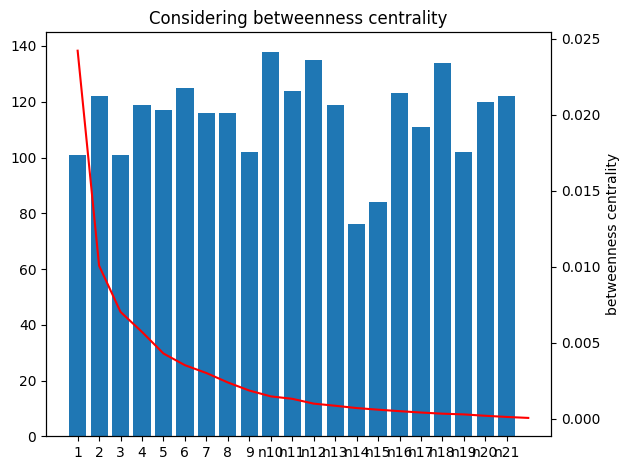

In [20]:
data_folder = Path(f'../../data/raw/random')
print(data_folder)
# Use glob to match files with a pattern
#f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_200*.bz2"))
print(files)
x=[]
itr_count=[]
for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    l=analyse.compute_param(df_d,0.05)
    num=l['tran_per'][-1]
    itr_count.append(num)

#plotting above as bar plot 
# sorting in ascending order

# uncomment below when need to plt in ascending order

# itr_count_arr=np.array(itr_count)
# ind=itr_count_arr.argsort()
# itr_count.sort()
# x=np.array(x)
# x=x[ind]

# SORT IN BETWEENNESS CENTRALITY DESCENDING ORDER

x_arr=np.array(x)
ind=x_arr.argsort()
x.sort()
itr_count=np.array(itr_count)
itr_count=itr_count[ind]

plt.bar(x,itr_count)
plt.twinx()


plt.plot(val,'r')
plt.title('Considering betweenness centrality')
plt.ylabel('betweenness centrality')
plt.xlabel('node set removed')
plt.tight_layout()
# print(f)

print(x)

#### Plotting betweenness centrality nodes on median time spent and degree plot

In [31]:
bet_cent_nodes = [214, 326, 271, 301, 366, 242, 160, 33, 369, 122, 51, 114, 132, 213, 309, 334, 283, 50, 158, 32, 73, 303]

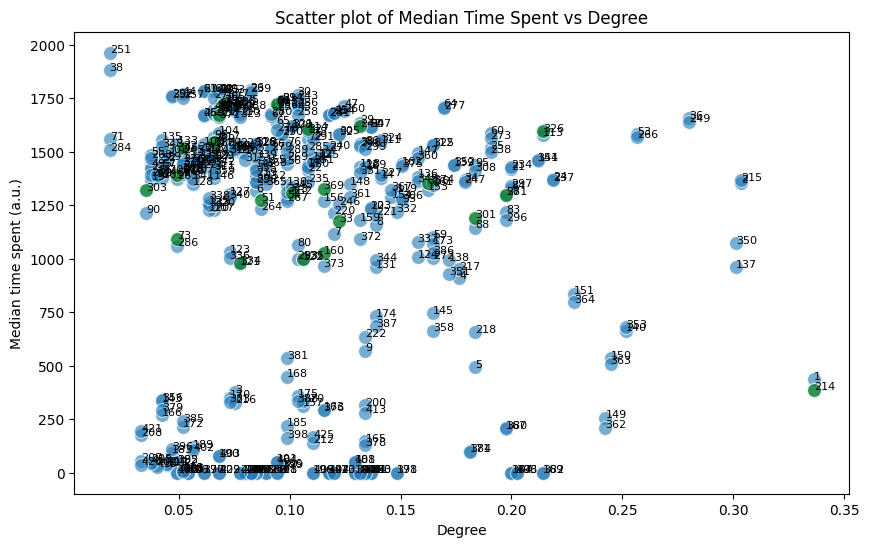

In [35]:
analyse.node_color(bet_cent_nodes,'g',G,df_nc)

## Finding Control Nodes


Node 0: FN  
Node 1: 251,38  
Node 2: 71,284  
Node 3: 1, 214  
Node 4: 149, 362


In [15]:
control_nodes=[251,38,71,284,1,214,149,362]

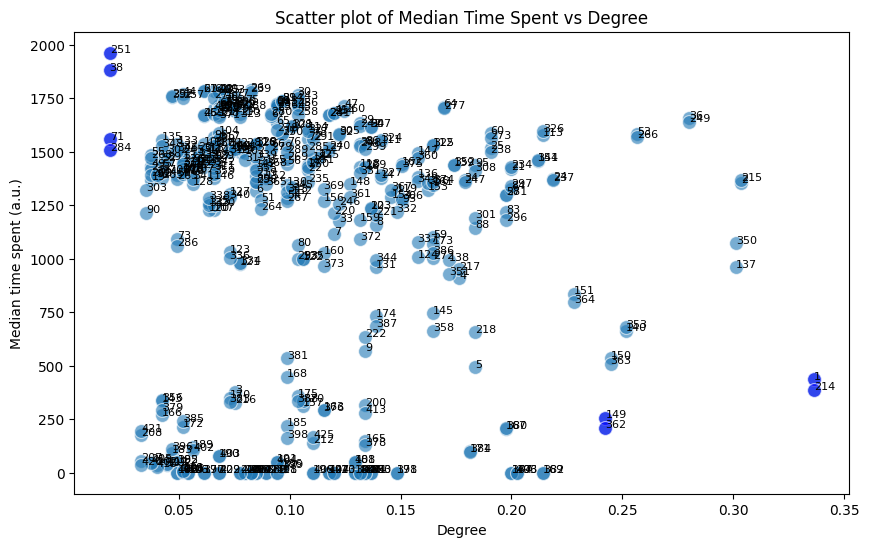

In [51]:
analyse.node_color(control_nodes,'b',G,df_nc)

## Plotting parameters


In [65]:
data_folder = Path('../../data/raw/check_control/')
files=glob.glob(str(data_folder / "itr_200*.bz2"))

print(files)
x=[]
itr_count=[]

# Initialize a dictionary to store parameter lists
transition_count = {}  # to store number of transitions
transition_time = {}  # to store transition times

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    #x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    # compute parameters
    params=analyse.compute_param(df_d,0.05)

    # store lists in dictionary
    transition_count[f"{name_suffix}"] = params["tran_per"]
    transition_time[f"{name_suffix}"] = params["trans"]
    # num=l['tran_per'][-1]

    # itr_count.append(num)

['../../data/raw/check_control/itr_200_1.bz2', '../../data/raw/check_control/itr_200_2.bz2', '../../data/raw/check_control/itr_200_3.bz2', '../../data/raw/check_control/itr_200_4.bz2', '../../data/raw/check_control/itr_200_fn.bz2']
Number of transitions / 100 iteration [5, 56, 107]
Number of transition [0, 2, 4, 5, 6, 7, 8, 11, 12, 13, 15, 18, 19, 21, 25, 27, 28, 29, 38, 39, 40, 42, 44, 48, 51, 52, 53, 58, 60, 62, 67, 69, 73, 74, 78, 79, 81, 84, 90, 91, 92, 93, 96, 97, 98, 99, 102, 103, 107, 109, 111, 113, 115, 116, 123, 124, 125, 127, 130, 131, 132, 133, 136, 137, 139, 140, 142, 145, 148, 149, 159, 160, 161, 165, 166, 169, 177, 178, 181, 182, 183, 185, 187, 189, 190, 191, 192, 194, 196, 198, 199]
Number of transition with more than one transition or a fall back [0, 12, 21, 29, 39, 40, 42, 44, 53, 74, 78, 79, 91, 103, 116, 124, 133, 136, 137, 140, 149, 159, 160, 161, 166, 177, 178, 181, 198]
Number of transitions / 100 iteration [1, 78, 132]
Number of transition [0, 1, 2, 5, 6, 7, 9, 1

In [66]:
transition_count.keys()


dict_keys(['1', '2', '3', '4', 'fn'])

In [67]:
node_order = np.array(['fn','1', '2', '3', '4'])
non=np.r_[np.argsort([transition_count[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]
non



array([3, 4, 1, 2, 0])

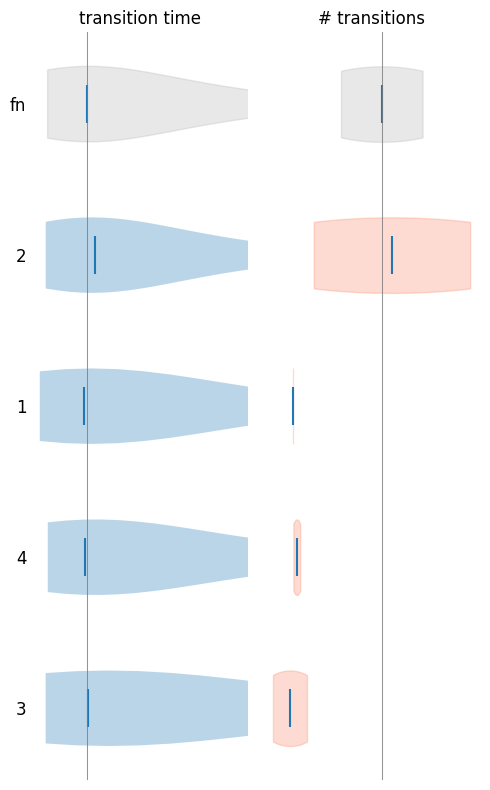

In [68]:
f,(ax1, ax2) = plt.subplots(1,2, figsize=(5,8),sharey = True)

_artists = ax1.violinplot(
    [transition_time[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(transition_time["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax2.violinplot(
    [np.diff(np.array(transition_count[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(transition_count["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()

Node 0: FN  
Node 1: 251,38  
Node 2: 71,284  
Node 3: 1, 214  
Node 4: 149, 362  

## All the regions get synchronised

In [4]:
df_nc_fn = reader.data_read_bz2('raw/FN/nc_200.bz2')
df_nc_peri = reader.data_read_bz2('raw/PERI/nc_200.bz2')

# resetting index for node community data  
df_r_fn = df_nc_fn.reset_index(drop=True)
df_r_peri = df_nc_peri.reset_index(drop=True)


In [133]:
def node_count(df):
# to find node count during formation of main cluster
    i=0
    f=5000
    # df=df_r_fn 
    time_list=[]
    node_count_list=[]
    while f < df.shape[0]:
        l=analyse.node_count(df.iloc[i:f,:])
        time_list.append(l['timestep'])
        node_count_list.append(l['node_count'])
        i=f
        f+=5000

    keys = ['time_list','nc_list']
    values = [time_list,node_count_list]
    sync_dict=dict(zip(keys,values))
    return sync_dict

In [134]:
FN_folder = Path('../../data/raw/FN/')
ENTI_folder = Path('../../data/raw/ENTI/')
ORBI_folder = Path('../../data/raw/ORBI/')
PERI_folder = Path('../../data/raw/PERI/')
PIR_folder = Path('../../data/raw/PIR/')
RE_folder = Path('../../data/raw/RE/')
BLA_folder = Path('../../data/raw/BLA/')
files=[]
folders=[FN_folder,ENTI_folder,ORBI_folder,PERI_folder,PIR_folder,RE_folder, BLA_folder]
for folder in folders:
    file=glob.glob(str(folder / "nc_200.bz2"))
    files.append(file)

print(files)




time_list=[]
node_count_list=[]
# x=[]
# itr_count=[]

# # Initialize a dictionary to store parameter lists
# transition_count = {}  # to store number of transitions
# transition_time = {}  # to store transition times
node=['FN','ENTI','ORBI','PERI','PIR','RE','BLA']
for f in files:

    # Extract the part of the filename after the underscore
    # file_stem = Path(f).stem  # e.g., "itr_bla"
    # name_suffix = file_stem.split("_")[2]
    #x.append(name_suffix)
    df_nc = pd.read_pickle(f[0], compression="bz2")
    df_r = df_nc.reset_index(drop=True)
    t=node_count(df_r)

    #taking only 1 transition
    time_list.append(t['time_list'][1])
    node_count_list.append(t['nc_list'][1])


t_df= pd.DataFrame(time_list)
nc_df=pd.DataFrame(node_count_list)

    


[['../../data/raw/FN/nc_200.bz2'], ['../../data/raw/ENTI/nc_200.bz2'], ['../../data/raw/ORBI/nc_200.bz2'], ['../../data/raw/PERI/nc_200.bz2'], ['../../data/raw/PIR/nc_200.bz2'], ['../../data/raw/RE/nc_200.bz2'], ['../../data/raw/BLA/nc_200.bz2']]


In [135]:
t_df=t_df.T
nc_df=nc_df.T

In [136]:
t_df.columns=node
nc_df.columns=node

In [137]:
nc_df

,FN,ENTI,ORBI,PERI,PIR,RE,BLA
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,2.0,1.0,1.0,1.0,1.0
4,2.0,1.0,1.0,1.0,1.0,2.0,1.0
...,...,...,...,...,...,...,...
1977,NaN,NaN,95.0,NaN,NaN,NaN,NaN
1978,NaN,NaN,94.0,NaN,NaN,NaN,NaN
1979,NaN,NaN,93.0,NaN,NaN,NaN,NaN
1980,NaN,NaN,90.0,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Main cluster formation during transition')

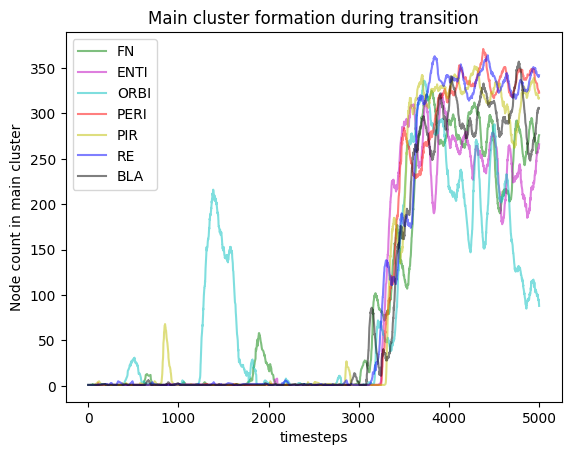

In [138]:
colors=['g','m','c','r','y','b','k']

for i,n in enumerate(node):
    plt.plot(t_df[n],nc_df[n],color=colors[i],alpha = 0.5,label=n)
    
plt.legend()
plt.xlabel('timesteps')
plt.ylabel('Node count in main cluster')
plt.title('Main cluster formation during transition')
        

# Time of Entry of all nodes grouped by community

Defining function for finding average TOE for given node community data

- Takes each node
- Calculates time when it first enters the main cluster
- Take median time spent for respective number of transitions


In [155]:
def avg_toe(df): 
    i=0
    f=5000
    # df=df_r_fn 
    toe=[]
    while f < df.shape[0]:
        mc=analyse.compute_main_cluster(df.iloc[i:f,:])
        t=analyse.compute_toe(df.iloc[i:f,:],mc)
        toe.append(t)
        i=f
        f+=5000
    # can use mean or median accordingly
    col_mean = np.median(np.array(toe),axis=0)
    return col_mean
    


In [156]:
FN_folder = Path('../../data/raw/FN/')
ENTI_folder = Path('../../data/raw/ENTI/')
ORBI_folder = Path('../../data/raw/ORBI/')
PERI_folder = Path('../../data/raw/PERI/')
PIR_folder = Path('../../data/raw/PIR/')
RE_folder = Path('../../data/raw/RE/')
BLA_folder= Path('../../data/raw/BLA')
files=[]
folders=[FN_folder,ENTI_folder,ORBI_folder,PERI_folder,PIR_folder,RE_folder,BLA_folder]
label=['FN','ENTI','ORBI','PERI','PIR','RE','BLA']
for folder in folders:
    file=glob.glob(str(folder / "nc_200.bz2"))
    files.append(file)

print(files)
toe=[]
for f in files: 
    df_nc = pd.read_pickle(f[0], compression="bz2")
    df_r = df_nc.reset_index(drop=True)
    mean_toe=avg_toe(df_r)
    toe.append(mean_toe)

# Sorting by communities
desired_order=list(reader.get_communities()['des_order'])
df_toe=pd.DataFrame(toe,index=label).T

# very powerful, whenever you concat any node data to community map, it automatically arranges in that order
toe_plot_data=pd.concat([reader.get_communities()['comm_map'].to_frame(),df_toe],axis=1)

[['../../data/raw/FN/nc_200.bz2'], ['../../data/raw/ENTI/nc_200.bz2'], ['../../data/raw/ORBI/nc_200.bz2'], ['../../data/raw/PERI/nc_200.bz2'], ['../../data/raw/PIR/nc_200.bz2'], ['../../data/raw/RE/nc_200.bz2'], ['../../data/raw/BLA/nc_200.bz2']]


In [157]:
toe_plot_data.columns=['community', 'FN', 'ENTI', 'ORBI', 'PERI', 'PIR', 'RE','BLA']


In [176]:
toe_plot_data

,community,FN,ENTI,ORBI,PERI,PIR,RE,BLA
0,MO,2706.0,3004.0,2577.5,3198.0,3150.0,2816.0,3218.0
1,MO,3655.0,3629.0,3632.5,3687.0,3609.0,3652.0,3679.0
2,MO,3451.0,3419.0,3435.5,3457.0,3406.0,3420.0,3465.0
3,MO,3481.0,3510.0,3461.0,3512.0,3459.0,3442.0,3493.0
4,MO,3470.0,3461.0,3479.0,3499.0,3444.0,3464.0,3493.0
...,...,...,...,...,...,...,...,...
421,HIND,1172.0,1518.0,964.0,1419.0,2052.5,1535.0,1168.0
422,HIND,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
423,HIND,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0
424,HIND,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0,4999.0


In [167]:
l=reader.get_communities()['comm_val']
l=l.to_dict()
l

{'MO': 56,
 'VIS': 50,
 'ORB': 34,
 'HTh': 44,
 'OLF': 36,
 'HIPP': 50,
 'MID': 70,
 'HIND': 86}

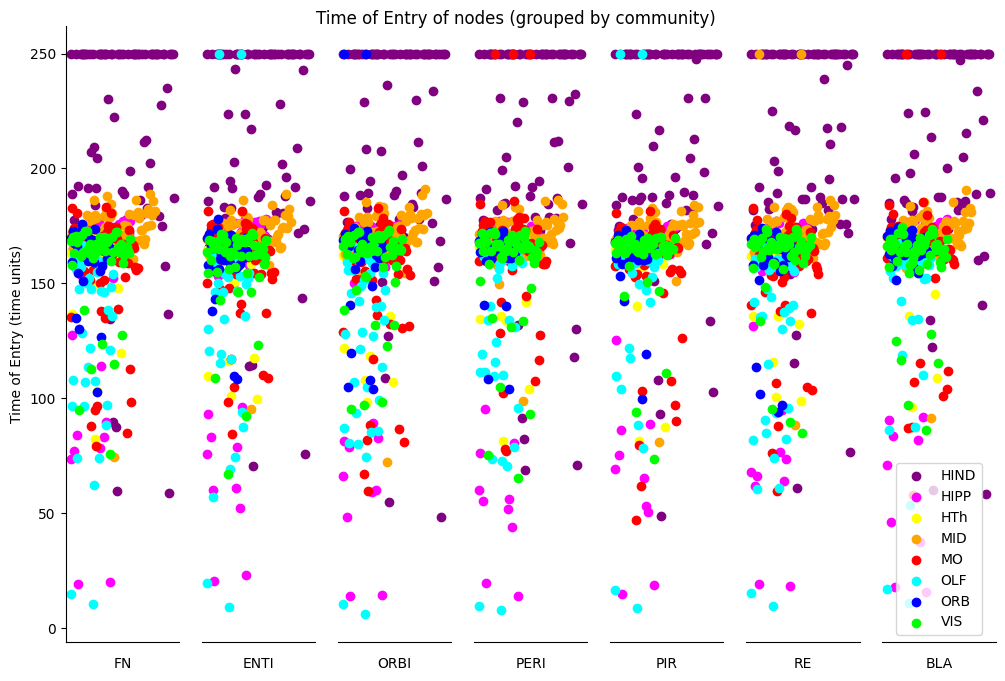

In [168]:
comm=['MO', 'VIS', 'ORB', 'HTh', 'OLF', 'HIPP', 'MID', 'HIND']

node_c_avi =  ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]

fig,ax=plt.subplots(1,7,sharex=True,sharey=True, figsize=(12,8))


node_c_nim = ['#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080']
col = dict(zip(comm,node_c_nim))
grouped=toe_plot_data.groupby('community')
for community, group in grouped:
    ax[0].scatter(range(0,l[community]),group['FN']*0.05,color=col[community],label=community)
    ax[0].set_ylabel('Time of Entry (time units)')
    #ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
    ax[0].set_xticks([50])
    ax[0].set_xticklabels([])
    ax[0].set_xlabel('FN')
    #ax[0].tick_params(axis="both", which="both", length=0)
    
    ax[1].scatter(range(0,l[community]),group['ENTI']*0.05,color=col[community],label=community)
    ax[1].set_xticks([50])
    ax[1].set_xticklabels([])
    ax[1].set_xlabel('ENTI')
    
    ax[2].scatter(range(0,l[community]),group['ORBI']*0.05,color=col[community],label=community)
    ax[2].set_xticks([50])
    ax[2].set_xticklabels([])
    ax[2].set_xlabel('ORBI')
    
    ax[3].scatter(range(0,l[community]),group['PERI']*0.05,color=col[community],label=community)
    ax[3].set_xticks([50])
    ax[3].set_xticklabels([])
    ax[3].set_xlabel('PERI')
    
    ax[4].scatter(range(0,l[community]),group['PIR']*0.05,color=col[community],label=community)
    ax[4].set_xticks([50])
    ax[4].set_xticklabels([])
    ax[4].set_xlabel('PIR')
    
    ax[5].scatter(range(0,l[community]),group['RE']*0.05,color=col[community],label=community)
    ax[5].set_xticks([50])
    ax[5].set_xticklabels([])
    ax[5].set_xlabel('RE')
    
    ax[6].scatter(range(0,l[community]),group['BLA']*0.05,color=col[community],label=community)
    ax[6].set_xticks([50])
    ax[6].set_xticklabels([])
    ax[6].set_xlabel('BLA')


# Remove outlines: Remove top/right spines from each subplot and hide most of the x-axis spines
for i, a in enumerate(ax):
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    
    # Hide the bottom spine for all subplots except the first one:
    if i != 0:
        a.spines['bottom'].set_visible(False)
        a.tick_params(bottom=False)  # Remove tick marks on the x-axis
        a.spines['left'].set_visible(False)
        a.tick_params(left=False) 
    else:
        a.spines['bottom'].set_visible(True)
        a.tick_params(bottom=True)
    
    # Ensure the left spine (y-axis) is visible:
    #a.spines['left'].set_visible(True)
    a.spines['bottom'].set_visible(True)
    a.tick_params(bottom=False)



plt.legend()
plt.suptitle('Time of Entry of nodes (grouped by community)',x=0.5,y=0.9)
plt.show()

## 